# N1 · 5 阶段 compaction 实况 (配套 L04)

填满一个上下文窗口, 看 `Compactor` 如何**逐级**触发 5 个阶段把 token 压回预算,
并画出 token 下降曲线。改 `BUDGET` / 历史规模, 观察阶段如何升级。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import provider, compaction, long_horizon, otel_trace, harness_eval
print("src 组件就绪 (默认 MockProvider, 无需 API key)")

src 组件就绪 (默认 MockProvider, 无需 API key)


In [2]:
from compaction import Compactor, total_tokens

# 造一段会撑爆窗口的历史: 1 条 system(pinned) + 20 条大 tool_result
messages = [{"role": "system", "content": "你是长任务 agent。", "pinned": True}]
for i in range(20):
    messages.append({"role": "user", "content": f"工具#{i} 输出: " + "x"*600, "kind": "tool_result"})

before = total_tokens(messages)
print(f"压缩前: {len(messages)} 条消息, {before} tokens")

压缩前: 21 条消息, 3043 tokens


In [3]:
BUDGET = before // 5            # 预算设成原来的 1/5, 逼出多级压缩
comp = Compactor(max_tokens=BUDGET)
new_msgs, events = comp.compact(messages)

print(f"预算 {BUDGET} tokens; 触发 {len(events)} 次压缩, 跨 {len({e.stage for e in events})} 个阶段\n")
for e in events:
    print(f"  Stage{e.stage} {e.name:18s} {e.tokens_before:5d} -> {e.tokens_after:5d}  (freed {e.freed})")
print(f"\n压缩后: {len(new_msgs)} 条, {total_tokens(new_msgs)} tokens (<= {BUDGET}: {total_tokens(new_msgs)<=BUDGET})")
print("system 仍在:", any(m.get('role')=='system' and m.get('kind')!='summary' for m in new_msgs))

预算 608 tokens; 触发 17 次压缩, 跨 1 个阶段

  Stage2 snip                3043 ->  2891  (freed 152)
  Stage2 snip                2891 ->  2739  (freed 152)
  Stage2 snip                2739 ->  2587  (freed 152)
  Stage2 snip                2587 ->  2435  (freed 152)
  Stage2 snip                2435 ->  2283  (freed 152)
  Stage2 snip                2283 ->  2131  (freed 152)
  Stage2 snip                2131 ->  1979  (freed 152)
  Stage2 snip                1979 ->  1827  (freed 152)
  Stage2 snip                1827 ->  1675  (freed 152)
  Stage2 snip                1675 ->  1523  (freed 152)
  Stage2 snip                1523 ->  1371  (freed 152)
  Stage2 snip                1371 ->  1219  (freed 152)
  Stage2 snip                1219 ->  1067  (freed 152)
  Stage2 snip                1067 ->   915  (freed 152)
  Stage2 snip                 915 ->   763  (freed 152)
  Stage2 snip                 763 ->   611  (freed 152)
  Stage2 snip                 611 ->   459  (freed 152)

压缩后: 4 条, 45

## token 随每次压缩下降 (阶段用颜色标注)

C:\Users\ericp\AppData\Local\Temp\ipykernel_43436\3318525360.py:14: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_43436\3318525360.py:14: UserWarning: Glyph 20960 (\N{CJK UNIFIED IDEOGRAPH-51E0}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_43436\3318525360.py:14: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_43436\3318525360.py:14: UserWarning: Glyph 21387 (\N{CJK UNIFIED IDEOGRAPH-538B}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_43436\3318525360.py:14: UserWarning: Glyph 32553 (\N{CJK UNIFIED IDEOGRAPH-7F29}) missing from font(s) DejaVu Sans.
  ax.legend(); p

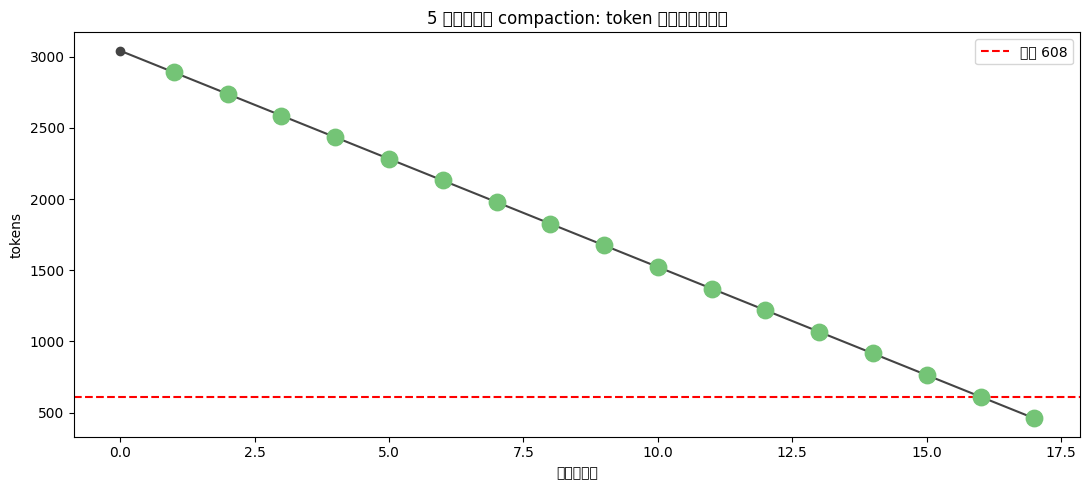

阶段序列: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]  (数字越大手段越重: 1截断 2丢弃 3局部摘要 4塌缩 5整窗重置)


In [4]:
import matplotlib.pyplot as plt

xs = list(range(len(events)+1))
ys = [before] + [e.tokens_after for e in events]
stages = [0] + [e.stage for e in events]

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(xs, ys, "-o", color="#444")
ax.axhline(BUDGET, ls="--", color="red", label=f"预算 {BUDGET}")
cmap = {1:"#9ecae1",2:"#74c476",3:"#fdae6b",4:"#fb6a4a",5:"#a50f15"}
for i,e in enumerate(events, start=1):
    ax.scatter([xs[i]],[ys[i]], s=140, color=cmap[e.stage], zorder=3)
ax.set_xlabel("第几次压缩"); ax.set_ylabel("tokens"); ax.set_title("5 阶段渐进式 compaction: token 逐级降到预算内")
ax.legend(); plt.tight_layout(); plt.show()
print("阶段序列:", stages[1:], " (数字越大手段越重: 1截断 2丢弃 3局部摘要 4塌缩 5整窗重置)")

**收获**: 轻手段(截断/丢弃)先上, 不够才升级到摘要/塌缩。system 永远保留。这就是生产级 context engineering 的核心——不是一刀切 summarize。